# Сверточные сети (Convolutional Neural Networks) 

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Для воспроизводимости результатов
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

PyTorch version: 2.10.0
Device: CPU


In [2]:
# Пути к данным
DATA_DIR = 'data'
IMAGES_DIR = os.path.join(DATA_DIR, 'train_images')
LABELS_PATH = os.path.join(DATA_DIR, 'train.csv')

# Параметры модели
IMG_HEIGHT = 350
IMG_WIDTH = 525
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
EPOCHS = 2
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Типы облаков для классификации
CLOUD_TYPES = ['Fish', 'Flower', 'Gravel', 'Sugar']

print(f"Images directory: {IMAGES_DIR}")
print(f"Cloud types: {CLOUD_TYPES}")

Images directory: data/train_images
Cloud types: ['Fish', 'Flower', 'Gravel', 'Sugar']


In [3]:
def rle_decode(mask_rle, shape=(1400, 2100)):
    """
    Декодирует RLE-маску в бинарную маску изображения
    
    Args:
        mask_rle: строка в формате Run-Length Encoding
        shape: исходный размер изображения (height, width)
    
    Returns:
        np.array: бинарная маска
    """
    if pd.isna(mask_rle):
        return np.zeros(shape, dtype=np.uint8)
    
    s = mask_rle.split()
    starts, lengths = [np.asarray(x, dtype=int) for x in (s[0:][::2], s[1:][::2])]
    starts -= 1  # RLE использует 1-индексацию
    ends = starts + lengths
    
    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    
    return img.reshape(shape, order='F')  # Порядок 'F' важен для этого датасета


def rle_encode(img):
    """Кодирует бинарную маску в RLE-формат (для сабмита)"""
    pixels = img.flatten(order='F')
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return ' '.join(str(x) for x in runs)

Статистика по типам облаков:
  Fish: 2781 размеченных изображений
  Flower: 2365 размеченных изображений
  Gravel: 2939 размеченных изображений
  Sugar: 3751 размеченных изображений


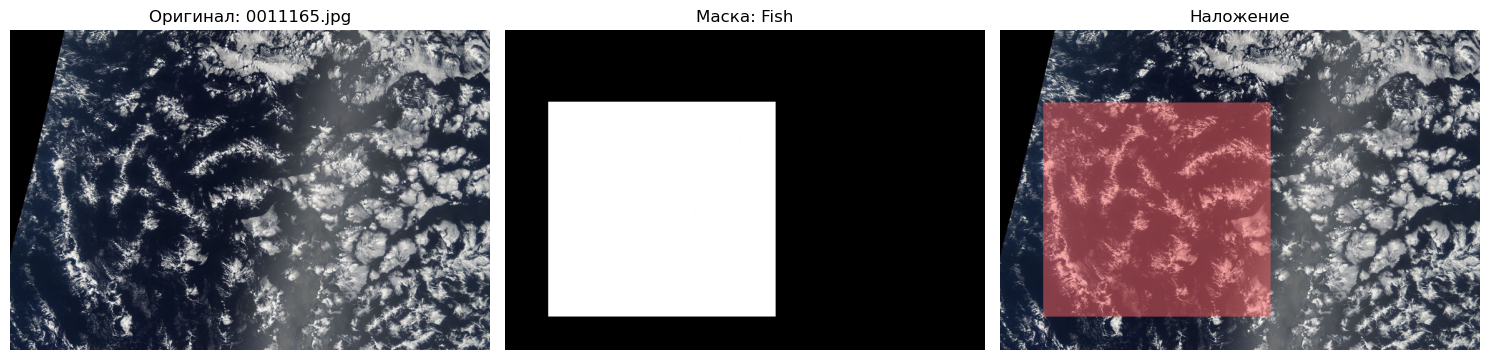

In [4]:
# Загрузка меток
df = pd.read_csv(LABELS_PATH)
df[['Image', 'Label']] = df['Image_Label'].str.split('_', expand=True)

# Статистика по типам облаков
print("Статистика по типам облаков:")
for cloud_type in CLOUD_TYPES:
    count = df[df['Label'] == cloud_type]['EncodedPixels'].notna().sum()
    print(f"  {cloud_type}: {count} размеченных изображений")

# Пример визуализации
def visualize_sample(image_name, label_type, df, images_dir):
    """Визуализирует изображение с маской облака"""
    row = df[(df['Image'] == image_name) & (df['Label'] == label_type)]
    if row.empty:
        print(f"Нет данных для {image_name} / {label_type}")
        return
    
    # Загрузка изображения
    img = Image.open(os.path.join(images_dir, image_name)).convert('RGB')
    
    # Декодирование маски
    mask_rle = row['EncodedPixels'].values[0]
    mask = rle_decode(mask_rle)
    
    # Визуализация
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(img)
    axes[0].set_title(f'Оригинал: {image_name}')
    axes[0].axis('off')
    
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title(f'Маска: {label_type}')
    axes[1].axis('off')
    
    # Наложение маски на изображение
    img_np = np.array(img)
    overlay = img_np.copy()
    overlay[mask > 0] = overlay[mask > 0] * 0.5 + np.array([255, 100, 100]) * 0.5
    axes[2].imshow(overlay.astype(np.uint8))
    axes[2].set_title('Наложение')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Попробуем визуализировать пример
sample_image = df[df['EncodedPixels'].notna()]['Image'].iloc[0]
sample_label = df[(df['Image'] == sample_image) & (df['EncodedPixels'].notna())]['Label'].iloc[0]
visualize_sample(sample_image, sample_label, df, IMAGES_DIR)

In [5]:
class CloudDataset(Dataset):
    """Dataset для сегментации облаков"""
    
    def __init__(self, images_dir, labels_df, label_type, transform=None, 
                 img_height=350, img_width=525):
        self.images_dir = images_dir
        self.label_type = label_type
        self.transform = transform
        self.img_height = img_height
        self.img_width = img_width
        
        # Фильтруем по типу облака и берём уникальные изображения
        self.image_names = labels_df[
            (labels_df['Label'] == label_type)
        ]['Image'].unique()
        
        # Словарь для быстрого доступа к маскам
        self.masks_dict = labels_df[
            labels_df['Label'] == label_type
        ].set_index('Image')['EncodedPixels'].to_dict()
    
    def __len__(self):
        return len(self.image_names)
    
    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        
        # Загрузка изображения
        img = Image.open(os.path.join(self.images_dir, img_name)).convert('RGB')
        
        # Получение маски
        mask_rle = self.masks_dict.get(img_name)
        mask = rle_decode(mask_rle, shape=(1400, 2100))
        
        # Ресайз изображения и маски
        img = img.resize((self.img_width, self.img_height), Image.BILINEAR)
        mask = Image.fromarray(mask).resize(
            (self.img_width, self.img_height), Image.NEAREST
        )
        mask = np.array(mask, dtype=np.float32)
        
        # Применение трансформаций к изображению
        if self.transform:
            img = self.transform(img)
        
        # Добавляем канал для маски [H, W] -> [1, H, W]
        mask = torch.from_numpy(mask).unsqueeze(0)
        
        return img, mask, img_name


# Трансформации
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225]),
])

In [6]:
class DoubleConv(nn.Module):
    """Блок: Conv → BN → ReLU → Conv → BN → ReLU"""
    
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
            
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    """U-Net для бинарной сегментации облаков"""
    
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Encoder
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature
        
        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)
        
        # Decoder
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2)
            )
            self.ups.append(DoubleConv(feature * 2, feature))
        
        # Output
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)
    
    def forward(self, x):
        skip_connections = []
        
        # Encoder path
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)
        
        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]
        
        # Decoder path
        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip = skip_connections[idx // 2]
            
            # Проверка и корректировка размеров
            if x.shape[2:] != skip.shape[2:]:
                x = torch.nn.functional.interpolate(
                    x, size=skip.shape[2:], mode='bilinear', align_corners=False
                )
            
            x = torch.cat([skip, x], dim=1)
            x = self.ups[idx + 1](x)
        
        return self.final_conv(x)

In [7]:
def dice_coefficient(pred, target, smooth=1e-6):
    """
    Вычисляет Dice coefficient между предсказанием и истиной
    """
    pred = torch.sigmoid(pred)  # Преобразуем логиты в вероятности
    
    pred_flat = pred.contiguous().view(-1)
    target_flat = target.contiguous().view(-1)
    
    intersection = (pred_flat * target_flat).sum()
    
    dice = (2. * intersection + smooth) / (
        pred_flat.sum() + target_flat.sum() + smooth
    )
    
    return dice


def dice_loss(pred, target, smooth=1e-6):
    """Dice Loss = 1 - Dice Coefficient"""
    return 1 - dice_coefficient(pred, target, smooth)


# Тест функции
if __name__ == "__main__":
    # Создаём тестовые данные
    pred_test = torch.randn(2, 1, 350, 525)
    target_test = torch.randint(0, 2, (2, 1, 350, 525)).float()
    
    print(f"Dice coefficient: {dice_coefficient(pred_test, target_test):.4f}")
    print(f"Dice loss: {dice_loss(pred_test, target_test):.4f}")

Dice coefficient: 0.4995
Dice loss: 0.5005


In [8]:
def train_one_epoch(model, dataloader, optimizer, device):
    """Обучение на одной эпохе"""
    model.train()
    epoch_loss = 0
    epoch_dice = 0
    
    # Итерируемся без tqdm
    for images, masks, _ in dataloader:
        images, masks = images.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        
        loss = dice_loss(outputs, masks)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        epoch_dice += dice_coefficient(outputs, masks).item()
    
    return epoch_loss / len(dataloader), epoch_dice / len(dataloader)


def validate(model, dataloader, device):
    """Валидация модели"""
    model.eval()
    epoch_dice = 0
    
    with torch.no_grad():
        for images, masks, _ in dataloader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            
            dice = dice_coefficient(outputs, masks).item()
            epoch_dice += dice
    
    return epoch_dice / len(dataloader)

In [9]:
# Разделение данных на train/val
from sklearn.model_selection import train_test_split

unique_images = df['Image'].unique().tolist()
train_images, val_images = train_test_split(
    unique_images, 
    test_size=0.2, 
    random_state=42
)

# Выбор типа облака для начала (можно расширить на все)
TARGET_CLOUD = 'Fish'  # 'Fish', 'Flower', 'Gravel', или 'Sugar'

# Создание датасетов
train_dataset = CloudDataset(
    images_dir=IMAGES_DIR,
    labels_df=df[df['Image'].isin(train_images)],  # Фильтруем по train_images
    label_type=TARGET_CLOUD,
    transform=train_transform,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH
)

val_dataset = CloudDataset(
    images_dir=IMAGES_DIR,
    labels_df=df[df['Image'].isin(val_images)],  # Фильтруем по val_images
    label_type=TARGET_CLOUD,
    transform=val_transform,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH
)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

Train samples: 4436, Val samples: 1110


In [10]:
import time
import torch
import torch.optim as optim
from tqdm.auto import tqdm

# Инициализация модели
model = UNet(in_channels=3, out_channels=1).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Хранение истории обучения
history = {'train_loss': [], 'train_dice': [], 'val_dice': []}

def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss, total_dice = 0, 0
    # leave=False убирает бар после завершения, чтобы не засорять ноутбук
    loop = tqdm(dataloader, desc='Training', leave=False, colour='green')
    
    for images, masks, _ in loop:
        images, masks = images.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = dice_loss(outputs, masks)
        loss.backward()
        optimizer.step()
        
        # Метрики текущего батча
        batch_dice = dice_coefficient(outputs, masks).item()
        total_loss += loss.item()
        total_dice += batch_dice
        
        # Обновляем бар в реальном времени
        loop.set_postfix(loss=f'{loss.item():.4f}', dice=f'{batch_dice:.4f}')
        
    return total_loss / len(dataloader), total_dice / len(dataloader)

def validate(model, dataloader, device):
    model.eval()
    total_dice = 0
    
    with torch.no_grad():
        loop = tqdm(dataloader, desc='Validating', leave=False, colour='blue')
        for images, masks, _ in loop:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            batch_dice = dice_coefficient(outputs, masks).item()
            total_dice += batch_dice
            loop.set_postfix(dice=f'{batch_dice:.4f}')
            
    return total_dice / len(dataloader)

# Основной цикл обучения
print(f"\nНачало обучения модели для типа облаков: {TARGET_CLOUD}")
print(f"Конфигурация: {EPOCHS} эпох | Batch Size: {BATCH_SIZE} | LR: {LEARNING_RATE}")
print("="*65)

best_dice = 0
best_epoch = 0

for epoch in range(EPOCHS):
    epoch_start = time.time()
    print(f"\n Epoch {epoch + 1}/{EPOCHS}")
    print("-" * 40)
    
    # Обучение
    train_loss, train_dice = train_one_epoch(model, train_loader, optimizer, DEVICE)
    
    # Валидация
    print("Оценка на валидации...", end=' ', flush=True)
    val_dice = validate(model, val_loader, DEVICE)
    print("Готово!")
    
    epoch_time = time.time() - epoch_start
    
    # Сохранение истории
    history['train_loss'].append(train_loss)
    history['train_dice'].append(train_dice)
    history['val_dice'].append(val_dice)
    
    # Логирование эпохи
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Время: {epoch_time:.2f}с | LR: {current_lr:.2e}")
    print(f"Train: Loss={train_loss:.4f}, Dice={train_dice:.4f}")
    print(f"Val:   Dice={val_dice:.4f} | Best: {max(val_dice, best_dice):.4f}")
    
    # Сохранение лучшей модели
    if val_dice > best_dice:
        best_dice = val_dice
        best_epoch = epoch + 1
        torch.save(model.state_dict(), f'best_model_{TARGET_CLOUD}.pth')
        print(f"Сохранена новая лучшая модель (Epoch {best_epoch})! Dice: {best_dice:.4f}")
    else:
        print(f"Нет улучшения. Лучший результат пока: {best_dice:.4f} (Epoch {best_epoch})")
        
    print("="*65)

print(f"\nОбучение завершено!")
print(f"Лучший результат: Val Dice = {best_dice:.4f} на эпохе {best_epoch}")
print(f"Файл модели сохранён: best_model_{TARGET_CLOUD}.pth")


Начало обучения модели для типа облаков: Fish
Конфигурация: 2 эпох | Batch Size: 8 | LR: 0.0001

 Epoch 1/2
----------------------------------------


Training:   0%|          | 0/555 [00:00<?, ?it/s]

Оценка на валидации... 

Validating:   0%|          | 0/139 [00:00<?, ?it/s]

Готово!
Время: 9974.11с | LR: 1.00e-04
Train: Loss=0.6399, Dice=0.3601
Val:   Dice=0.3459 | Best: 0.3459
Сохранена новая лучшая модель (Epoch 1)! Dice: 0.3459

 Epoch 2/2
----------------------------------------


Training:   0%|          | 0/555 [00:00<?, ?it/s]

Оценка на валидации... 

Validating:   0%|          | 0/139 [00:00<?, ?it/s]

Готово!
Время: 9410.55с | LR: 1.00e-04
Train: Loss=0.5996, Dice=0.4004
Val:   Dice=0.3869 | Best: 0.3869
Сохранена новая лучшая модель (Epoch 2)! Dice: 0.3869

Обучение завершено!
Лучший результат: Val Dice = 0.3869 на эпохе 2
Файл модели сохранён: best_model_Fish.pth


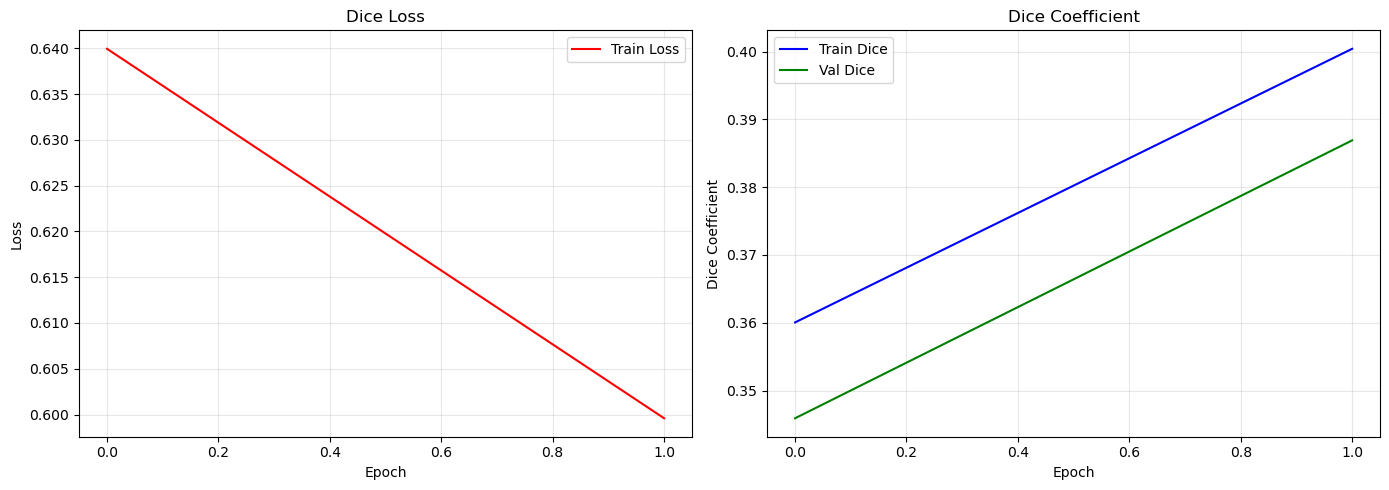

In [11]:
# Графики обучения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss', color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Dice Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Dice coefficient
axes[1].plot(history['train_dice'], label='Train Dice', color='blue')
axes[1].plot(history['val_dice'], label='Val Dice', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice Coefficient')
axes[1].set_title('Dice Coefficient')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

Визуализация предсказаний для Fish:


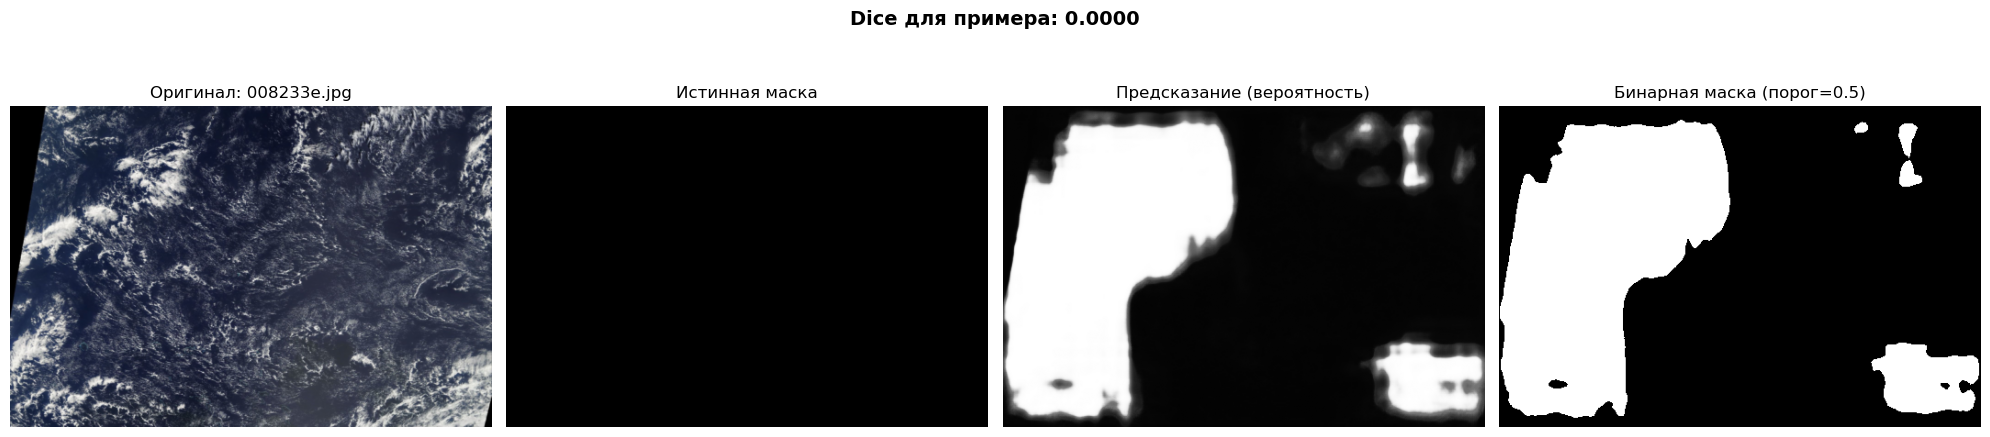

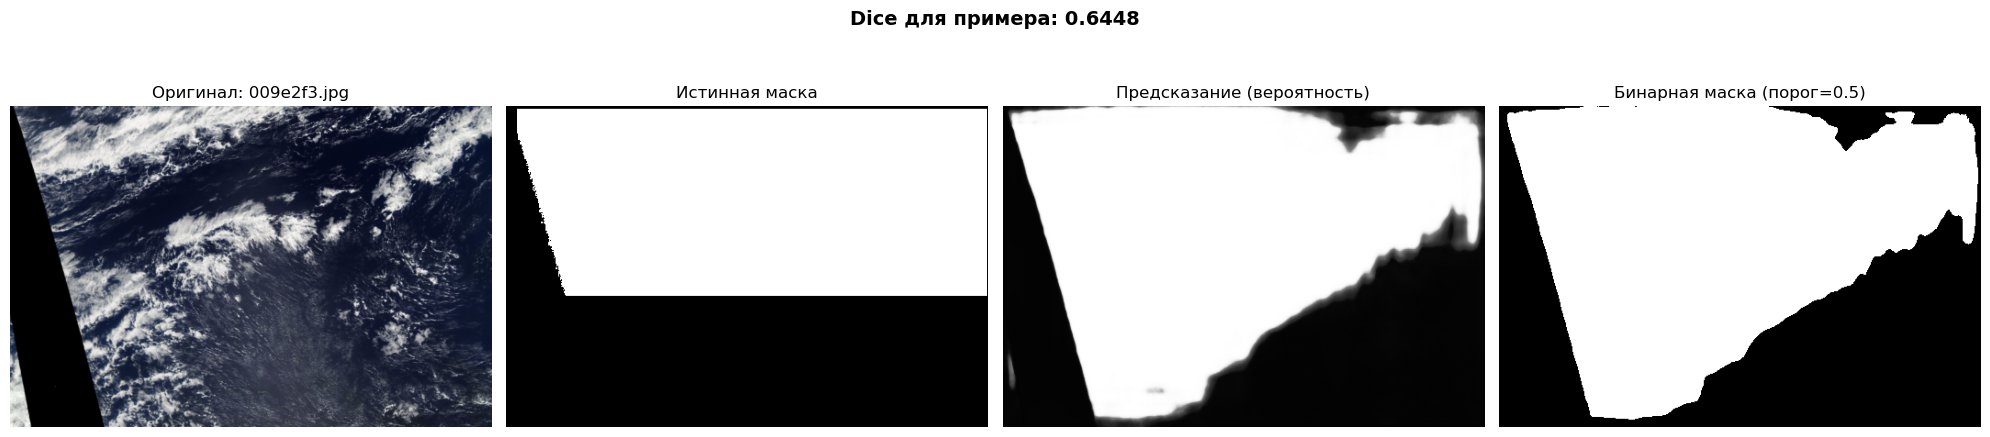

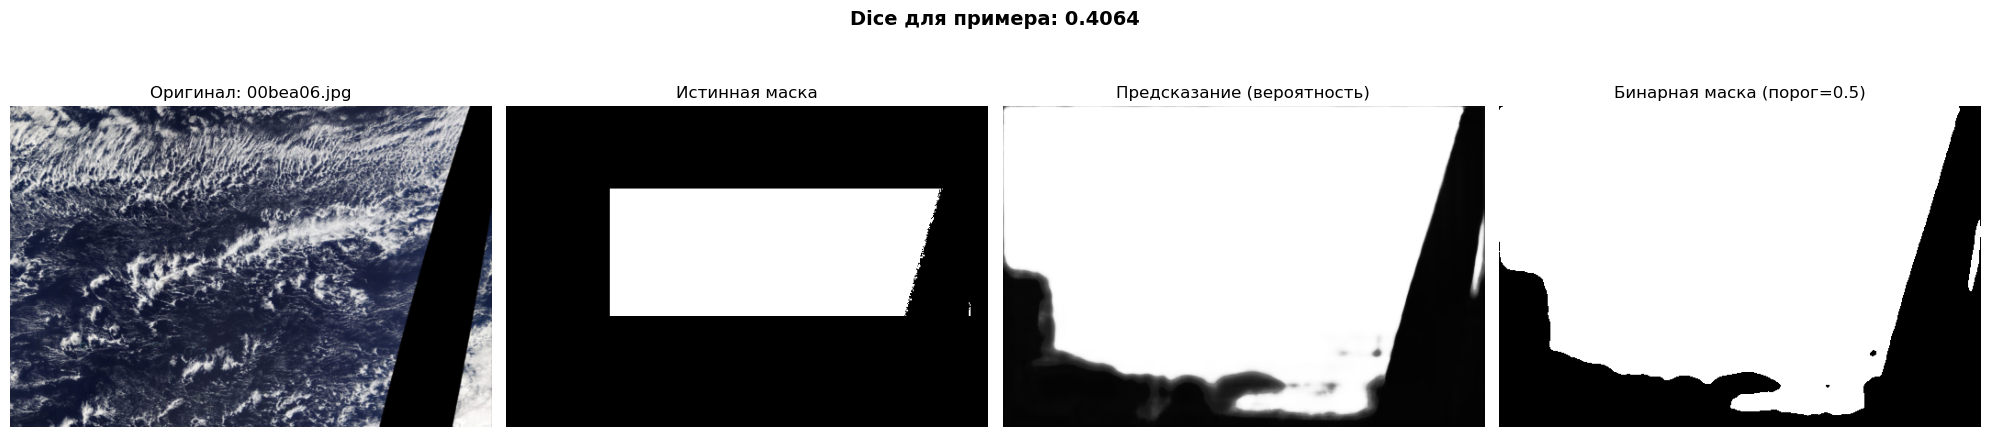

In [12]:
def predict_and_show(model, dataset, idx, device, threshold=0.5):
    """Визуализирует предсказание модели на примере из датасета"""
    model.eval()
    
    img, mask, img_name = dataset[idx]
    
    # Предсказание
    with torch.no_grad():
        img_tensor = img.unsqueeze(0).to(device)  # [1, C, H, W]
        pred = torch.sigmoid(model(img_tensor))
        pred = pred.squeeze().cpu().numpy()
    
    # Подготовка для визуализации
    img_np = img.permute(1, 2, 0).numpy()
    img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_np = np.clip(img_np, 0, 1)
    
    mask_np = mask.squeeze().numpy()
    pred_binary = (pred > threshold).astype(np.uint8)
    
    # Визуализация
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    axes[0].imshow(img_np)
    axes[0].set_title(f'Оригинал: {img_name}')
    axes[0].axis('off')
    
    axes[1].imshow(mask_np, cmap='gray')
    axes[1].set_title('Истинная маска')
    axes[1].axis('off')
    
    axes[2].imshow(pred, cmap='gray', vmin=0, vmax=1)
    axes[2].set_title(f'Предсказание (вероятность)')
    axes[2].axis('off')
    
    axes[3].imshow(pred_binary, cmap='gray')
    axes[3].set_title(f'Бинарная маска (порог={threshold})')
    axes[3].axis('off')
    
    # Вычисление Dice для этого примера
    dice = dice_coefficient(
        torch.tensor(pred).unsqueeze(0).unsqueeze(0),
        torch.tensor(mask_np).unsqueeze(0).unsqueeze(0)
    ).item()
    plt.suptitle(f'Dice для примера: {dice:.4f}', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return pred


# Показать несколько примеров из валидации
print(f"Визуализация предсказаний для {TARGET_CLOUD}:")
for i in range(3):
    predict_and_show(model, val_dataset, i, DEVICE)

In [13]:
# Сохранение финальной модели
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'config': {
        'cloud_type': TARGET_CLOUD,
        'img_size': (IMG_HEIGHT, IMG_WIDTH),
        'dice_final': best_dice
    }
}, f'cloud_model_{TARGET_CLOUD}_final.pth')

print(f"Модель сохранена: cloud_model_{TARGET_CLOUD}_final.pth")
print(f"Финальный Dice: {best_dice:.4f}")

# Сохранение истории обучения
pd.DataFrame(history).to_csv(f'training_history_{TARGET_CLOUD}.csv', index=False)
print(f"История обучения: training_history_{TARGET_CLOUD}.csv")

Модель сохранена: cloud_model_Fish_final.pth
Финальный Dice: 0.3869
История обучения: training_history_Fish.csv
